In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

from math import ceil
from keras.models import Sequential
from keras.layers import Dense, Activation
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, InputLayer
from tensorflow.keras.models import Sequential
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from tensorflow.keras.regularizers import L2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Bidirectional, Dropout)
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error

In [106]:
df = pd.read_csv("pvtest.csv", parse_dates=['Time']).set_index('Time')
df = df[['Edaily','Dci','Dcp','Dcu','Temp1']]
df['hour'] = df.index.hour
df[:5]

C:\Users\Colin\AppData\Local\Temp\ipykernel_43868\3714259055.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("pvtest.csv", parse_dates=['Time']).set_index('Time')


,Edaily,Dci,Dcp,Dcu,Temp1,hour
Time,,,,,,
2021-01-20 07:45:00,0.0,0.0,0,0,0.0,7
2021-01-20 07:50:00,0.0,0.0,0,0,0.0,7
2021-01-20 07:55:00,0.0,0.0,0,0,0.0,7
2021-01-20 08:00:00,0.0,0.0,0,0,0.0,8
2021-01-20 08:05:00,0.0,0.0,0,0,0.0,8


**Splitten**

In [107]:
end_train = ceil(len(df)*0.8)
df_train = df[:end_train]
df_test = df[end_train:]

df_train[:5]

,Edaily,Dci,Dcp,Dcu,Temp1,hour
Time,,,,,,
2021-01-20 07:45:00,0.0,0.0,0,0,0.0,7
2021-01-20 07:50:00,0.0,0.0,0,0,0.0,7
2021-01-20 07:55:00,0.0,0.0,0,0,0.0,7
2021-01-20 08:00:00,0.0,0.0,0,0,0.0,8
2021-01-20 08:05:00,0.0,0.0,0,0,0.0,8


In [108]:
x_train_raw = df_train
y_train_raw = df_train[['Dcp']] # double [] gets as dataframe not as series

x_test_raw = df_test
y_test_raw = df_test[['Dcp']]

In [109]:
scaler_x = StandardScaler()
scaler_x.fit(x_train_raw)

x_train_std = scaler_x.transform(x_train_raw)
x_test_std = scaler_x.transform(x_test_raw)

scaler_y = StandardScaler()
scaler_y.fit(y_train_raw)

y_train_std = scaler_y.transform(y_train_raw)
y_test_std = scaler_y.transform(y_test_raw)

x_train_std.shape, y_train_std.shape

((2836, 6), (2836, 1))

In [110]:
def restructure_data(x, y, window, horizon):
    
    # Was bin ich froh, das es dynamische Typen gibt,
    # sonst müsste ich so einen scheiß ja gar nicht machen
    window = int(window)
    horizon = int(horizon)
    
    x_ = []
    y_ = []
    
    idx_range = range(len(x) - (window + horizon))
    for idx in idx_range:
        x_.append(x[idx:idx+window])
        y_.append(y[idx+window+horizon])
        
    return np.array(x_), np.array(y_)
    

In [111]:
window = int(3 * (60 / 5)) # 3 hours, 5 minute intervals
horizon = 1 # 5 minutes, 5 minute intervals

x_train, y_train = restructure_data(x_train_std, y_train_std, window, horizon)
x_test, y_test = restructure_data(x_test_std, y_test_std, window, horizon)

# n windows, 36 entries each window, each entry has 6 parameters
display(x_train.shape, y_train.shape)

indicators = int(x_train.shape[2])
display(indicators)

(2799, 36, 6)

(2799, 1)

6

**Note:** why not split test and training now? the order is no longer relevant and it would not be necessary to do everything twice

c:\Users\Colin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_36                │ (None, 36, 128)        │        36,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_37                │ (None, 36, 128)        │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_58 (LSTM)                  │ (None, 16)             │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,737 (565.38 KB)

 Trainable params: 144,737 (565.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.4726 - mae: 0.3677 - val_loss: 0.2708 - val_mae: 0.2861
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3047 - mae: 0.2976 - val_loss: 0.1582 - val_mae: 0.2111
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.2799 - mae: 0.2763 - val_loss: 0.1421 - val_mae: 0.2104
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.2401 - mae: 0.2557 - val_loss: 0.1620 - val_mae: 0.2220
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.2262 - mae: 0.2472 - val_loss: 0.1430 - val_mae: 0.1990
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.2269 - mae: 0.2435 - val_loss: 0.2129 - val_mae: 0.2308
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2067 - mae: 0.2347 - val_loss: 0.1468 - val_mae: 0.2058
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2263 - mae: 0.2436 - val_loss: 0.1587 - val_mae: 0.2191


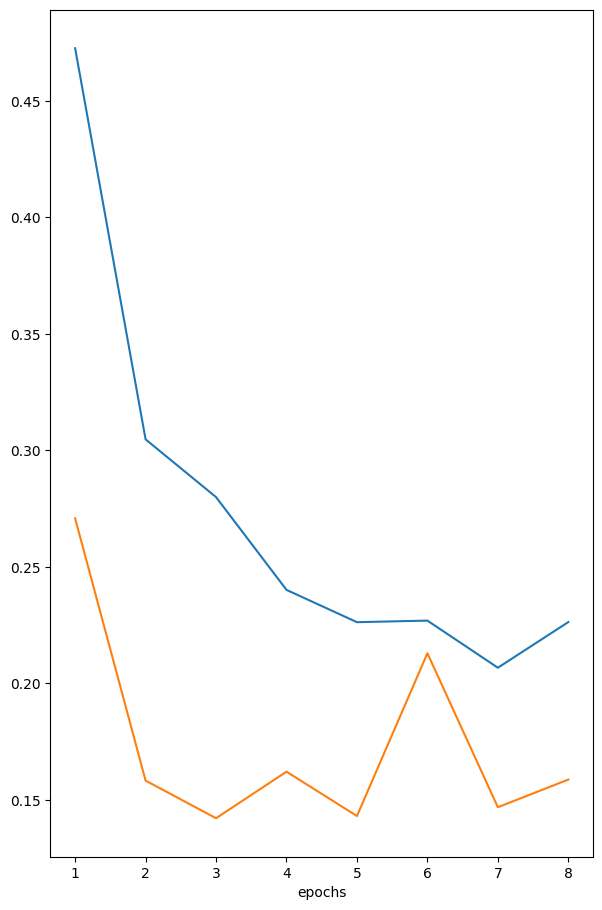

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(window, indicators)))
model.add(Bidirectional(LSTM(units=16, return_sequences=True, dropout=0.2))) # doppelt so viele outputs
model.add(Bidirectional(LSTM(units=64, return_sequences=True, dropout=0.2))) # doppelt so viele outputs
# model.add(Bidirectional(LSTM(units=32, return_sequences=True, dropout=0.2)))
# model.add(Bidirectional(LSTM(units=32, return_sequences=True, dropout=0.2)))
model.add(LSTM(units=32, dropout=0.2))
model.add(Dense(units=16, activation='relu')) # simple at the end
model.add(Dropout(0.2)) # prevent Overfitting
model.add(Dense(units=1)) # one neuron output
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
model.summary()


early = EarlyStopping(monitor='val_loss', patience=5)
check = ModelCheckpoint(filepath='consumption_power_model.keras',
    monitor='val_loss', save_best_only=True)

history = model.fit(x_train, y_train,
    epochs=100, batch_size=128,
    validation_data=(x_test, y_test),
    callbacks=[early, check])

loss_train = history.history['loss']
loss_test = history.history['val_loss']

plt.xlabel('epochs')
plt.plot(range(1, len(loss_train)+1), loss_train)
plt.plot(range(1, len(loss_test)+1), loss_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
mae, model predictions 84.631


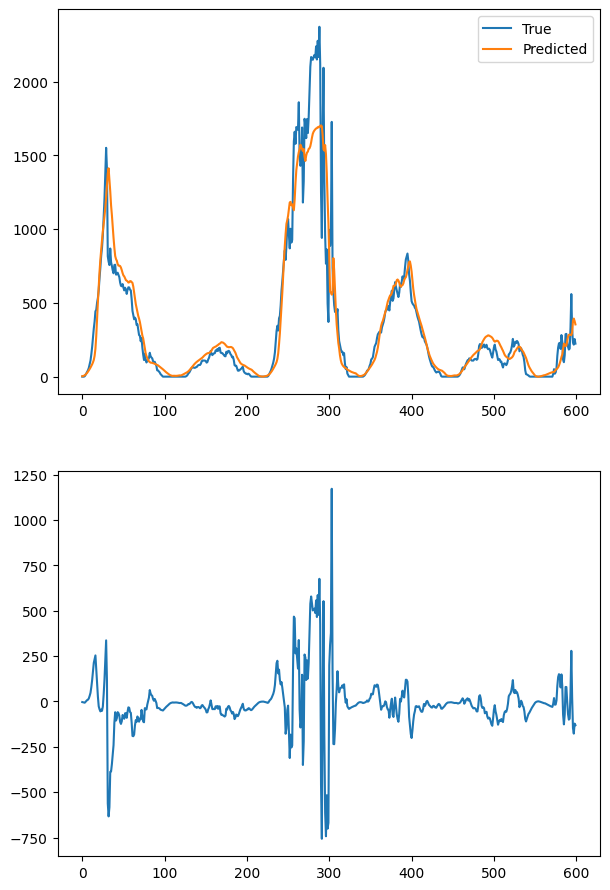

In [145]:
model = load_model('consumption_power_model.keras')

# ~isn't this just y_test?~ These are the unscaled values
# ignore the index as the predicted values don't have one either
y_true = y_test_raw[window+horizon:].values

y_pred = model.predict(x_test)
y_pred_org = scaler_y.inverse_transform(y_pred)

mae_model = mean_absolute_error(y_true, y_pred_org)
print('mae, model predictions {:.3f}'.format(mae_model))

_, ((sub)) = plt.subplots(2, 1)

rng_min = 0
rng_max = 600

sub[0].plot(y_true[rng_min:rng_max] , label='True')
sub[0].plot(y_pred_org[rng_min:rng_max], label='Predicted')
sub[0].legend()

sub[1].plot((y_true - y_pred_org)[rng_min:rng_max])


mae, model predictions 73.348
